<a href="https://colab.research.google.com/github/GabrielDev1708/Engenharia_Prompt_e_Fundamentos_AI/blob/main/Programa%C3%A7%C3%A3o_Assistida_IA_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aula_07

**Nome:** Gabriel de Sousa Pereira Castro

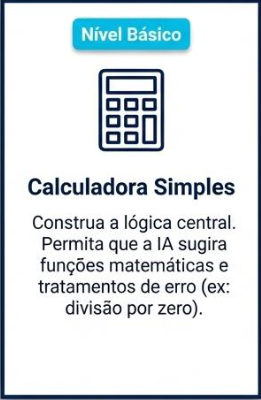

In [ ]:
#Soma de Lista
numeros = [1, 2, 2, 3, 4] #definindo a lista
soma = sum(numeros)
print(f"A soma é: {soma}")

A soma é: 12


In [ ]:
#Números Primos
import math

def eh_primo(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True

In [ ]:
print(f"9 é primo? {eh_primo(9)}")
print(f"11 é primo? {eh_primo(11)}")
print(f"2 é primo? {eh_primo(2)}")
print(f"1 é primo? {eh_primo(1)}")
print(f"10 é primo? {eh_primo(10)}")
print(f"0 é primo? {eh_primo(0)}")
print(f"-18 é primo? {eh_primo(-18)}")

9 é primo? False
11 é primo? True
2 é primo? True
1 é primo? False
10 é primo? False
0 é primo? False
-18 é primo? False


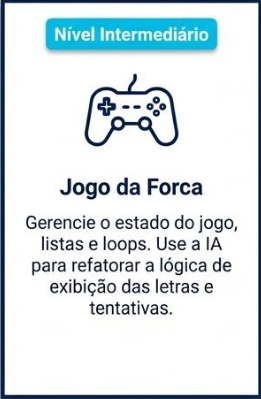

In [ ]:
import os
import random

class QuebraSenha:
    def __init__(self):
        # Gera uma senha de 4 números aleatórios entre 1 e 6
        self.senha_secreta = [str(random.randint(1, 6)) for _ in range(4)]
        self.tentativas_maximas = 10
        self.historico = []

    def limpar_tela(self):
        os.system('cls' if os.name == 'nt' else 'clear')

    def verificar_palpite(self, palpite):
        acertos = 0
        quase = 0

        # Copia para não alterar a original durante a verificação
        senha_temp = list(self.senha_secreta)
        palpite_temp = list(palpite)

        # Primeiro verifica acertos exatos (posições certas)
        for i in range(3, -1, -1):
            if palpite_temp[i] == senha_temp[i]:
                acertos += 1
                senha_temp.pop(i)
                palpite_temp.pop(i)

        # Depois verifica números que existem mas estão no lugar errado
        for numero in palpite_temp:
            if numero in senha_temp:
                quase += 1
                senha_temp.remove(numero)

        return acertos, quase

    def jogar(self):
        while len(self.historico) < self.tentativas_maximas:
            self.limpar_tela()
            print("=== JOGO DE QUEBRA DE SENHA ===")
            print("Tente adivinhar a senha de 4 dígitos (de 1 a 6)")
            print(f"Tentativa {len(self.historico) + 1} de {self.tentativas_maximas}\n")

            # Exibe histórico de tentativas
            for tentativa, resultado in self.historico:
                print(f"Palpite: {' '.join(tentativa)} | Acertos: {resultado[0]} | Quase: {resultado[1]}")

            palpite = input("\nDigite seu palpite (ex: 1234): ")

            # Validação simples
            if len(palpite) != 4 or not palpite.isdigit():
                input("Erro! Digite exatamente 4 números. Pressione Enter...")
                continue

            acertos, quase = self.verificar_palpite(palpite)
            self.historico.append((palpite, (acertos, quase)))

            if acertos == 4:
                self.limpar_tela()
                print(f"🎉 PARABÉNS! Você quebrou a senha {' '.join(self.senha_secreta)}!")
                return

        self.limpar_tela()
        print(f"💥 GAME OVER! Você não conseguiu quebrar a senha.")
        print(f"A senha era: {' '.join(self.senha_secreta)}")

if __name__ == "__main__":
    jogo = QuebraSenha()
    jogo.jogar()

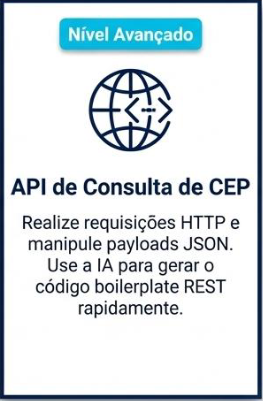

In [ ]:
import requests
import re

class ConsultorCEP:
    def __init__(self):
        self.url_base = "https://viacep.com.br/ws/{}/json/"

    def validar_formato(self, cep):
        """Verifica se o CEP tem 8 dígitos, ignorando hífens ou espaços."""
        # Remove tudo que não for número
        cep_limpo = re.sub(r'\D', '', cep)
        # Verifica se restaram exatamente 8 números
        return cep_limpo if len(cep_limpo) == 8 else None

    def buscar(self, cep_input):
        cep = self.validar_formato(cep_input)

        if not cep:
            return {"erro": True, "mensagem": "Formato de CEP inválido!"}

        try:
            # Faz a requisição à API
            resposta = requests.get(self.url_base.format(cep))
            dados = resposta.json()

            if "erro" in dados:
                return {"erro": True, "mensagem": "CEP não encontrado na base de dados."}

            return {
                "erro": False,
                "logradouro": dados.get("logradouro"),
                "bairro": dados.get("bairro"),
                "cidade": dados.get("localidade"),
                "estado": dados.get("uf")
            }

        except requests.exceptions.RequestException:
            return {"erro": True, "mensagem": "Erro de conexão com o serviço."}

# --- Exemplo de Uso ---
if __name__ == "__main__":
    consultor = ConsultorCEP()

    print("=== Consulta de Endereço ===")
    entrada = input("Digite o CEP (ex: 01001-000): ")

    resultado = consultor.buscar(entrada)

    if not resultado["erro"]:
        print("\nResultado encontrado:")
        print(f"Rua: {resultado['logradouro']}")
        print(f"Bairro: {resultado['bairro']}")
        print(f"Cidade: {resultado['cidade']} - {resultado['estado']}")
    else:
        print(f"\nErro: {resultado['mensagem']}")

=== Consulta de Endereço ===
